Implement a neural network from scratch using NumPy to approximate f(x) = (x^e)^x

In [2]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')

In [10]:
#Samples
def f(x):
    return x**np.exp(x)

n_hidden = 10
n_samples = 1000

x_vals = np.linspace(0, 1, 100)
random = np.random.choice(x_vals, size=n_samples, replace=True)
x_i = np.array([[r, f(r)] for r in random])

Two layer network

In [14]:
X = x_i[:, 0].reshape(1, -1)
X = np.vstack([X, np.ones((1, n_samples))])
T = x_i[:, 1].reshape(1, -1)

w1 = np.random.randn(n_hidden, 2) * 0.5
w2 = np.random.randn(1, n_hidden + 1) * 0.5

def h(a): #Sigmoid function
    return 1 / (1 + np.exp(-a))

def train_step(X, T, w1, w2, lr=0.1):
    # Forward pass
    inner = w1 @ X
    Z = h(inner)
    Z_aug = np.vstack([Z, np.ones((1, n_samples))])
    Y = w2 @ Z_aug

    # Output error
    delta_output = Y - T

    # Hidden layer error (exclude bias column!)
    delta_hidden = Z * (1 - Z) * (w2[:, :-1].T @ delta_output)

    # Update weights
    w2 = w2 - lr * (delta_output @ Z_aug.T) / n_samples
    w1 = w1 - lr * (delta_hidden @ X.T) / n_samples

    return w1, w2


In [15]:
epochs = 100000

for epoch in range(epochs):
    w1, w2 = train_step(X, T, w1, w2)

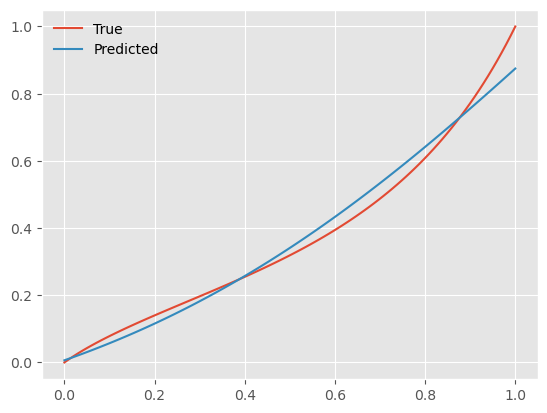

In [ ]:
# Compare the fitted function with the true function on the training grid
x_test = np.linspace(0, 1, 100).reshape(1, -1)
x_test_aug = np.vstack([x_test, np.ones((1, 100))])

inner = w1 @ x_test_aug 
z = h(inner)
z_aug = np.vstack([z, np.ones((1, 100))])
y_pred = w2 @ z_aug

plt.plot(x_test.flatten(), f(x_test).flatten(), label='True')
plt.plot(x_test.flatten(), y_pred.flatten(), label='Predicted')
plt.legend(frameon = False)
plt.show()